In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('product_usage_events.csv')
df.head()

,date,team,workflow,source,sessions,completed,accepted_output,flagged_for_review,avg_minutes_saved,median_confidence,user_rating,notes
0,2026-08-01,Sales,Lead summary,email,42,35,29,3,8.5,0.74,4.1,normal day
1,2026-08-01,Sales,Lead summary,manual,18,12,8,2,6.0,0.61,3.8,normal day
2,2026-08-01,Support,Reply draft,queue,55,48,39,6,4.5,0.82,4.0,normal day
3,2026-08-01,Support,Reply draft,manual,11,8,5,1,3.0,0.68,NaN,missing rating
4,2026-08-01,Product,Feedback clustering,csv upload,12,9,6,2,14.0,0.59,3.6,small sample


In [3]:
df.shape

(41, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                41 non-null     str    
 1   team                41 non-null     str    
 2   workflow            41 non-null     str    
 3   source              41 non-null     str    
 4   sessions            41 non-null     int64  
 5   completed           41 non-null     int64  
 6   accepted_output     41 non-null     int64  
 7   flagged_for_review  41 non-null     int64  
 8   avg_minutes_saved   41 non-null     float64
 9   median_confidence   40 non-null     float64
 10  user_rating         40 non-null     float64
 11  notes               41 non-null     str    
dtypes: float64(3), int64(4), str(5)
memory usage: 4.0 KB


In [5]:
df.describe()

,sessions,completed,accepted_output,flagged_for_review,avg_minutes_saved,median_confidence,user_rating
count,41.000000,41.000000,41.000000,41.000000,41.000000,40.000000,40.000000
mean,35.292683,28.073171,22.268293,3.243902,8.139024,0.710500,3.890000
std,31.716907,28.683088,26.661793,2.808741,3.904157,0.118212,0.436066
min,5.000000,4.000000,2.000000,1.000000,1.500000,0.520000,2.100000
25%,13.000000,10.000000,6.000000,1.000000,4.200000,0.625000,3.700000
50%,24.000000,15.000000,10.000000,2.000000,8.400000,0.685000,3.900000
75%,53.000000,43.000000,35.000000,4.000000,11.200000,0.802500,4.100000
max,140.000000,126.000000,119.000000,12.000000,14.400000,0.950000,4.900000


In [6]:
df['workflow'].value_counts()

workflow
Lead summary           14
Feedback clustering    14
Reply draft            13
Name: count, dtype: int64

In [7]:
df['team'].value_counts()

team
Sales      14
Support    13
Product    13
product     1
Name: count, dtype: int64

In [8]:
df['team'] = df['team'].replace({'product':'Product'})

In [9]:
df['team'].value_counts()

team
Sales      14
Product    14
Support    13
Name: count, dtype: int64

In [10]:
df['source'].value_counts()

source
manual        19
email          8
queue          7
csv upload     7
Name: count, dtype: int64

In [11]:
df['notes'].value_counts()

notes
normal day                         27
new prompt version started          6
small sample                        2
missing rating                      1
team casing differs                 1
traffic spike from demo account     1
duplicate export row                1
confidence missing as text          1
review policy changed mid-day       1
Name: count, dtype: int64

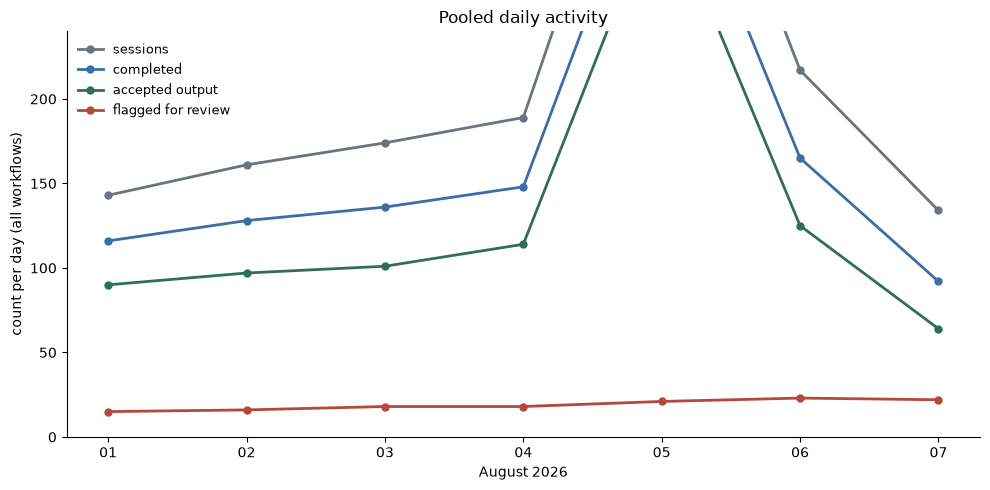

In [12]:
METRICS = ["sessions", "completed", "accepted_output", "flagged_for_review"]
COLOURS = {"sessions": "#6B7280", "completed": "#3A6EA5",
           "accepted_output": "#2E6F55", "flagged_for_review": "#B4483C"}

daily = df.groupby("date")[METRICS].sum()

fig, ax = plt.subplots(figsize=(10, 5))
for m in METRICS:
    ax.plot(daily.index.str[-2:], daily[m], "-o", ms=5, lw=2,
            color=COLOURS[m], label=m.replace("_", " "))

ax.set_ylabel("count per day (all workflows)")
ax.set_xlabel("August 2026")
ax.set_ylim(0, 240)
ax.set_title("Pooled daily activity")
ax.legend(fontsize=9, frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Unusually high activity on 5th August

In [13]:
df[df['date']=='2026-08-05']

,date,team,workflow,source,sessions,completed,accepted_output,flagged_for_review,avg_minutes_saved,median_confidence,user_rating,notes
24,2026-08-05,Sales,Lead summary,email,140,126,119,2,12.0,0.95,4.9,traffic spike from demo account
25,2026-08-05,Sales,Lead summary,email,140,126,119,2,12.0,0.95,4.9,duplicate export row
26,2026-08-05,Sales,Lead summary,manual,28,20,15,2,6.5,0.67,4.0,normal day
27,2026-08-05,Support,Reply draft,queue,72,60,47,9,4.2,0.87,4.2,normal day
28,2026-08-05,Support,Reply draft,manual,16,12,8,2,3.4,0.73,3.8,normal day
29,2026-08-05,Product,Feedback clustering,csv upload,24,15,10,3,13.9,0.64,3.8,normal day
30,2026-08-05,Product,Feedback clustering,manual,9,7,4,1,11.0,NaN,3.5,confidence missing as text


Hence, high activity on 5th August is due to a demo account and it's duplicate row. Since these rows are not genuine sessions as those in a "normal day", we can drop these

In [14]:
clean_df = df[~df.notes.isin(["duplicate export row", "traffic spike from demo account"])]

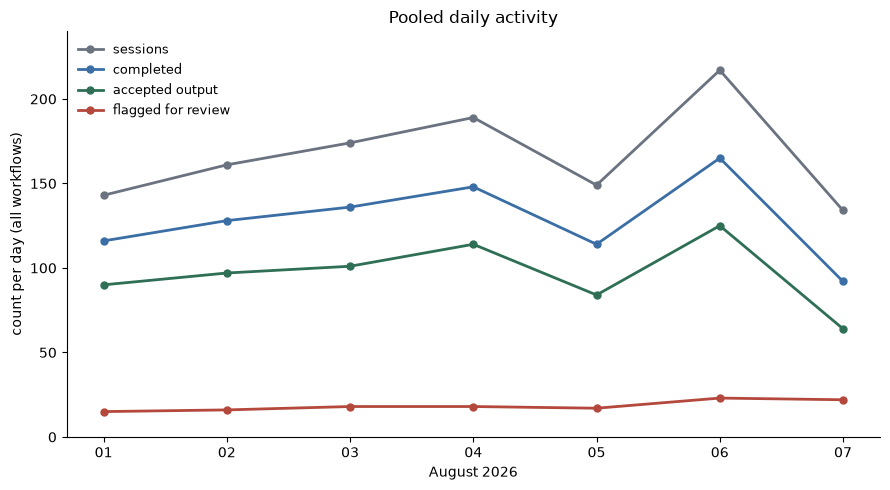

In [15]:
METRICS = ["sessions", "completed", "accepted_output", "flagged_for_review"]
COLOURS = {"sessions": "#6B7280", "completed": "#3A6EA5",
           "accepted_output": "#2E6F55", "flagged_for_review": "#B4483C"}

daily = clean_df.groupby("date")[METRICS].sum()

fig, ax = plt.subplots(figsize=(9, 5))
for m in METRICS:
    ax.plot(daily.index.str[-2:], daily[m], "-o", ms=5, lw=2,
            color=COLOURS[m], label=m.replace("_", " "))

ax.set_ylabel("count per day (all workflows)")
ax.set_xlabel("August 2026")
ax.set_ylim(0, 240)
ax.set_title("Pooled daily activity")
ax.legend(fontsize=9, frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

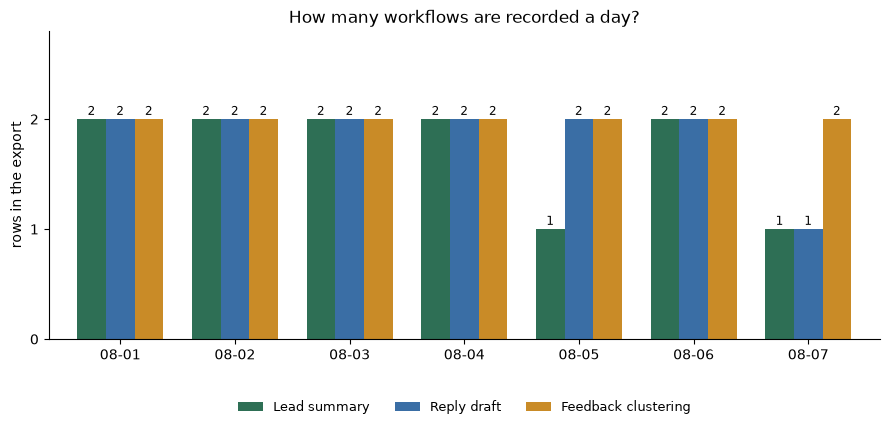

In [16]:
ORDER = ["Lead summary", "Reply draft", "Feedback clustering"]

rows = (clean_df.pivot_table(index="date", columns="workflow",
                             values="source", aggfunc="count")
        .reindex(columns=ORDER).fillna(0))

ax = rows.plot(kind="bar", figsize=(9, 4.5), rot=0, width=0.75,
               color=["#2E6F55", "#3A6EA5", "#C98B27"])

for c in ax.containers:
    ax.bar_label(c, fmt="%d", fontsize=8.5, padding=1)

ax.set_xticklabels([d[-5:] for d in rows.index])
ax.set_ylabel("rows in the export")
ax.set_xlabel("")
ax.set_ylim(0, 2.8)
ax.set_yticks([0, 1, 2])
ax.set_title("How many workflows are recorded a day?")
ax.legend(title="", fontsize=9, frameon=False, ncol=3, loc="lower center",
          bbox_to_anchor=(0.5, -0.28))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Each workflow is recorded twice a day with the exception of 5th August and 7th August. We know from above that on 5th August, Lead Summary was recorded thrice - twice for email and once for the manual source. The email rows were duplicates and so they were dropped which bring the final count of Lead Summary to one. 

In [17]:
df[df['date']=='2026-08-07']

,date,team,workflow,source,sessions,completed,accepted_output,flagged_for_review,avg_minutes_saved,median_confidence,user_rating,notes
37,2026-08-07,Sales,Lead summary,email,61,49,39,5,8.6,0.81,4.2,normal day
38,2026-08-07,Support,Reply draft,queue,30,17,8,12,1.5,0.91,2.1,review policy changed mid-day
39,2026-08-07,Product,Feedback clustering,csv upload,31,18,12,4,14.4,0.67,3.9,normal day
40,2026-08-07,Product,Feedback clustering,manual,12,8,5,1,11.1,0.58,3.6,normal day


On 7th August, Lead Summary and Reply Draft were recorded once and both for the automatic sources

In [18]:
workflow_group = clean_df.groupby('workflow')

In [19]:
workflow_group['sessions'].mean()

workflow
Feedback clustering    14.785714
Lead summary           37.500000
Reply draft            39.230769
Name: sessions, dtype: float64

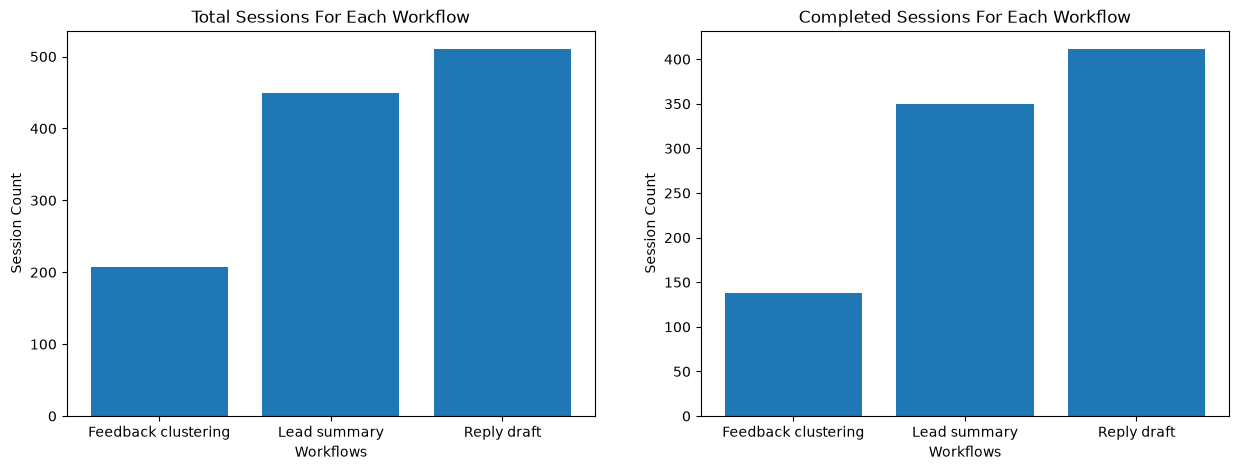

In [20]:
total_sessions = workflow_group['sessions'].sum()
completed_sessions = workflow_group['completed'].sum()
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].bar(total_sessions.index, total_sessions)
ax[1].bar(completed_sessions.index, completed_sessions)
ax[0].set_title("Total Sessions For Each Workflow")
ax[0].set_xlabel("Workflows")
ax[0].set_ylabel("Session Count")
ax[1].set_title("Completed Sessions For Each Workflow")
ax[1].set_xlabel("Workflows")
ax[1].set_ylabel("Session Count")
plt.show()

Reply Draft has the most amount of sessions both in total and completed while Feedback has the least amount of sessions. 

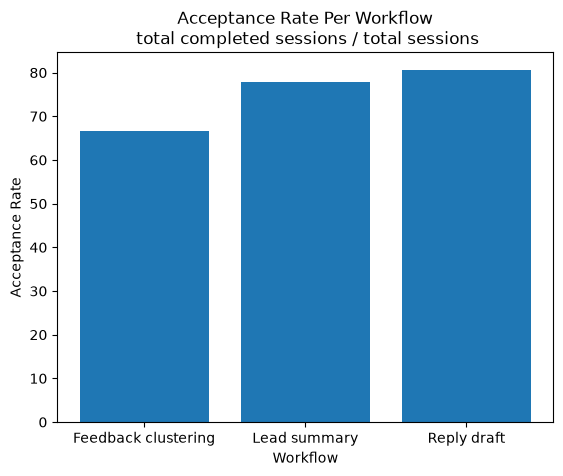

In [21]:
acceptance_rate = round((completed_sessions / total_sessions)*100,2)
plt.bar(acceptance_rate.index, acceptance_rate)
plt.title("Acceptance Rate Per Workflow\n total completed sessions / total sessions")
plt.xlabel("Workflow")
plt.ylabel("Acceptance Rate")
plt.show()

Acceptance rate is the amount of sessions completed out of the total sessions recorded. In this case Reply Draft and Lead Summary both have a good acceptance rate of between 75%-80%

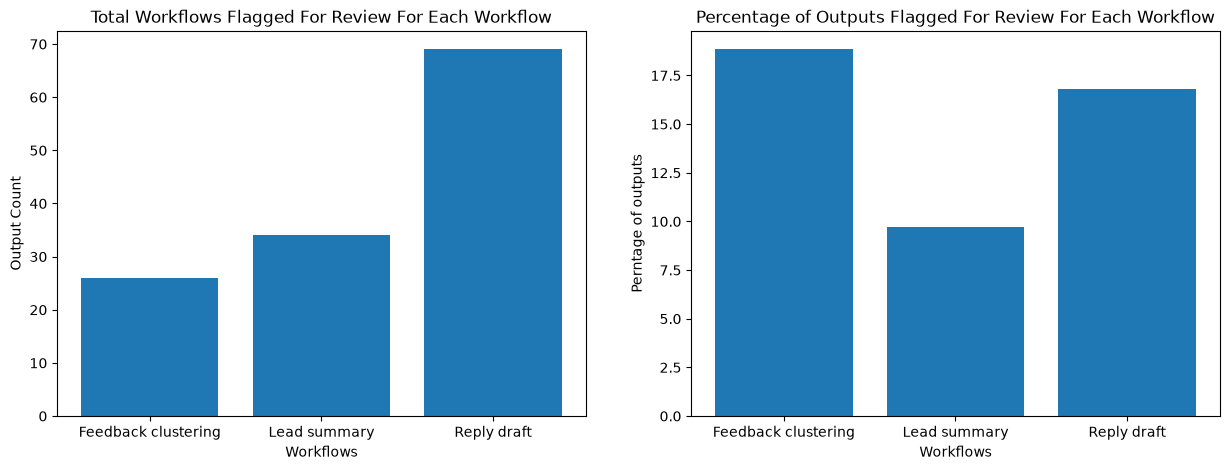

In [22]:
flagged = workflow_group['flagged_for_review'].sum()
flagged_prop = round((flagged / completed_sessions)*100, 2)

fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].bar(flagged.index, flagged)
ax[1].bar(flagged_prop.index, flagged_prop)
ax[0].set_title("Total Workflows Flagged For Review For Each Workflow")
ax[0].set_xlabel("Workflows")
ax[0].set_ylabel("Output Count")
ax[1].set_title("Percentage of Outputs Flagged For Review For Each Workflow")
ax[1].set_xlabel("Workflows")
ax[1].set_ylabel("Perntage of outputs")
plt.show()

Feedback clustering has the worst completion rate as around 18% of the outputs are flagged for review. Lead summary has a better rate at around 10%. 

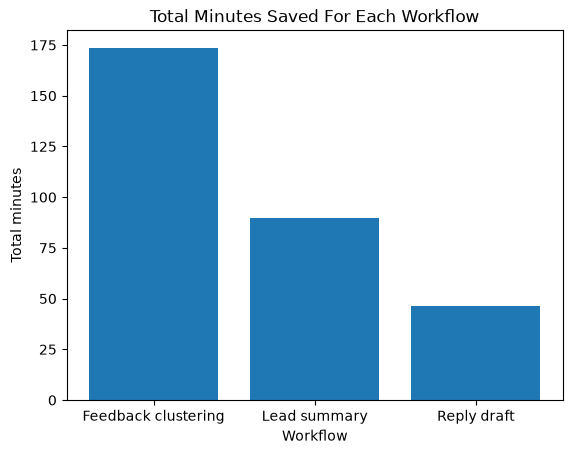

In [23]:
saved = workflow_group['avg_minutes_saved'].sum()
plt.bar(saved.index, saved)
plt.title("Total Minutes Saved For Each Workflow")
plt.xlabel("Workflow")
plt.ylabel("Total minutes")
plt.show()

Feedback clustering shows the highest amount of minutes saved which makes sense since it has the least number of outputs flagged for review despite having the worst rate. The overall count of outputs flagged review is still less than Reply draft. 

Based on the data, the number of outputs accepted by the user + number of outputs flagged for review is NOT equal to the number of completed sessions for each row. This is assuming there exists a one to one relationship between completed sessions and accepted outputs. 

In [24]:
clean_df['residuals'] = clean_df['completed'] - clean_df['accepted_output'] - clean_df['flagged_for_review']

In [25]:
workflow_group = clean_df.groupby('workflow')

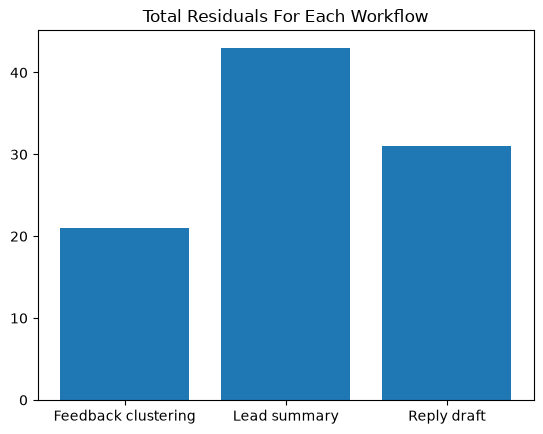

In [26]:
residuals = workflow_group['residuals'].sum()
plt.bar(residuals.index, residuals)
plt.title("Total Residuals For Each Workflow")
plt.show()

Lead summary has the highest number of residual outputs. 

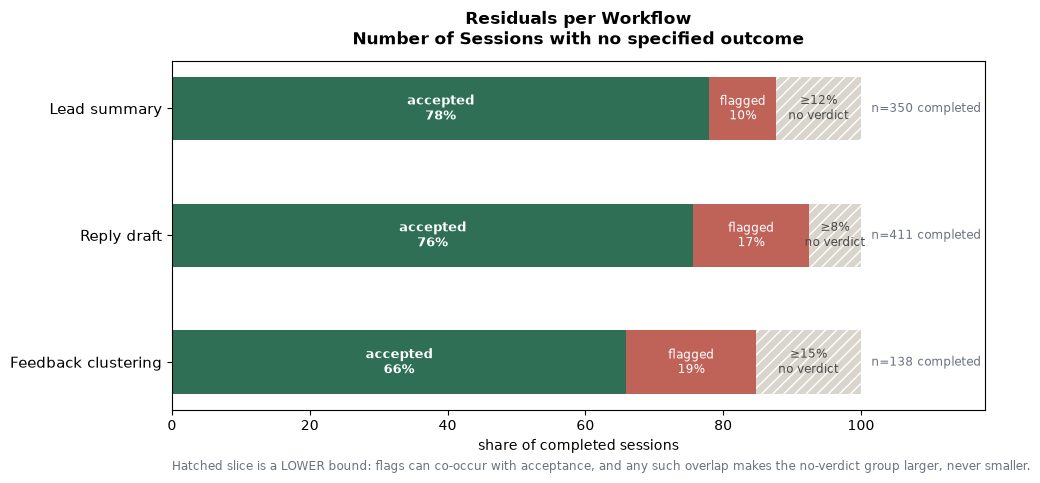

In [27]:
ORDER = ["Lead summary", "Reply draft", "Feedback clustering"]
g = clean_df.groupby("workflow")[["completed", "accepted_output", "flagged_for_review", "residuals"]].sum().loc[ORDER]
y = np.arange(len(g))[::-1]
h = 0.5
fig, ax = plt.subplots(figsize=(10.5, 5))
for i, wf in zip(y, g.index):
    c, a, f, r = g.loc[wf, ["completed", "accepted_output", "flagged_for_review", "residuals"]]
    pa, pf, pr = a / c * 100, f / c * 100, r / c * 100
    ax.barh(i, pa, h, color="#2E6F55")
    ax.barh(i, pf, h, left=pa, color="#B4483C", alpha=.85)
    ax.barh(i, pr, h, left=pa + pf, color="#D9D5CC", hatch="///", edgecolor="white", linewidth=0)
    ax.text(pa / 2, i, f"accepted\n{pa:.0f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    ax.text(pa + pf / 2, i, f"flagged\n{pf:.0f}%", ha="center", va="center", color="white", fontsize=8.5)
    ax.text(pa + pf + pr / 2, i, f"≥{pr:.0f}%\nno verdict", ha="center", va="center", fontsize=8.5, color="#4A4A4A")
    ax.text(101.5, i, f"n={int(c)} completed", va="center", fontsize=8.5, color="#6B7280")

ax.set_yticks(y); ax.set_yticklabels(g.index, fontsize=10.5)
ax.set_xlim(0, 118); ax.set_xlabel("share of completed sessions")
ax.set_title("Residuals per Workflow\nNumber of Sessions with no specified outcome",
                loc="center", fontsize=12, fontweight="bold", pad=12)
ax.text(0, -0.85, "Hatched slice is a LOWER bound: flags can co-occur with acceptance, "
        "and any such overlap makes the no-verdict group larger, never smaller.",
        fontsize=8.5, color="#6B7280", transform=ax.get_yaxis_transform())
plt.tight_layout()
plt.show()

Lead summary despite having the most number of residuals still has the highest acceptance rate whereas Feedback Clustering has the lowest with high flag rate as well as high proportion of residuals

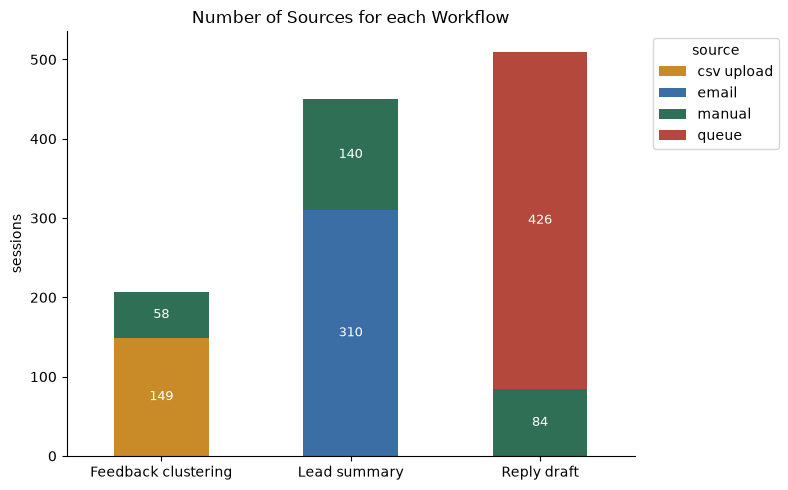

In [28]:
mix = clean_df.pivot_table(index="workflow", columns="source",
                        values="sessions", aggfunc="sum").fillna(0)
ax = mix.plot(kind="bar", stacked=True, figsize=(8, 5), rot=0,
              color=["#C98B27", "#3A6EA5", "#2E6F55", "#B4483C"])

for c in ax.containers:
    ax.bar_label(c, labels=[f"{int(v)}" if v else "" for v in c.datavalues],
                 label_type="center", color="white", fontsize=9)

ax.set_ylabel("sessions")
ax.set_xlabel("")
ax.set_title("Number of Sources for each Workflow")
ax.legend(title="source", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

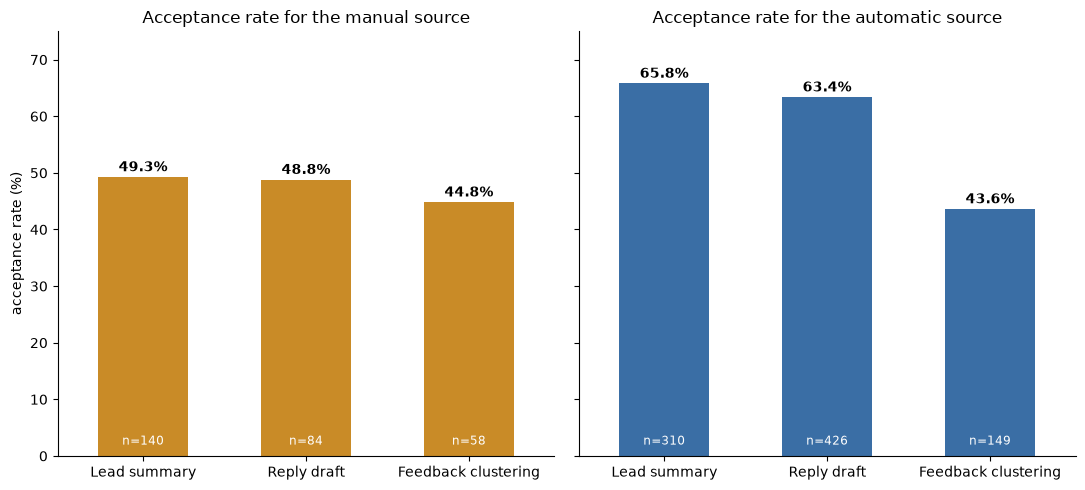

In [29]:
man = (clean_df[clean_df.source == "manual"].groupby("workflow")[["sessions", "accepted_output"]].sum())
man["accept_rate"] = man.accepted_output / man.sessions * 100
man = man.sort_values("accept_rate", ascending=False)


auto = (clean_df[clean_df.source != "manual"].groupby("workflow")[["sessions", "accepted_output"]].sum())
auto["accept_rate"] = auto.accepted_output / auto.sessions * 100
auto = auto.sort_values("accept_rate", ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
man.accept_rate.plot(kind="bar", ax=ax[0], rot=0,
                          color="#C98B27", width=0.55)

for i, (wf, r) in enumerate(man.accept_rate.items()):
    ax[0].text(i, r + 1, f"{r:.1f}%", ha="center", fontweight="bold")
    ax[0].text(i, 2, f"n={int(man.sessions[wf])}", ha="center",
            color="white", fontsize=8.5)

auto.accept_rate.plot(kind="bar", ax=ax[1], rot=0,
                          color="#3A6EA5", width=0.55)

for i, (wf, r) in enumerate(auto.accept_rate.items()):
    ax[1].text(i, r + 1, f"{r:.1f}%", ha="center", fontweight="bold")
    ax[1].text(i, 2, f"n={int(auto.sessions[wf])}", ha="center",
            color="white", fontsize=8.5)

ax[0].set_ylabel("acceptance rate (%)")
ax[0].set_xlabel("")
ax[0].set_ylim(0, 75)
ax[0].set_title("Acceptance rate for the manual source")
ax[0].spines[["top", "right"]].set_visible(False)

ax[1].set_xlabel("")
ax[1].set_ylim(0, 75)
ax[1].set_title("Acceptance rate for the automatic source")
ax[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

For the manual sources, all workflows have similar acceptance rate. However, for automatic sources Lead summary has the highest acceptance rate. For feedback clustering, the acceptance rate drops a little for the automatic source. However, as shown above, Reply draft has the highest overall acceptance rate even though by source Lead summary is the highest. 

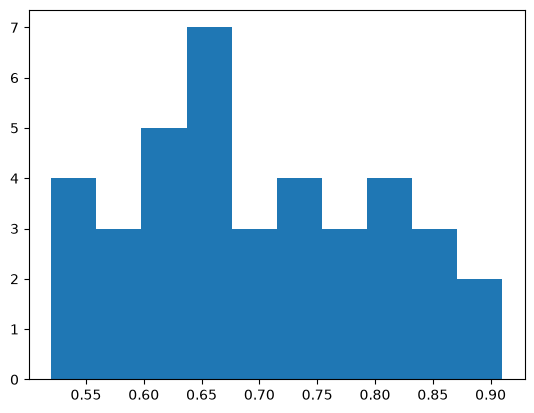

In [30]:
plt.hist(clean_df['median_confidence'])
plt.show()

In [31]:
clean_df["acceptance_rate"] = clean_df.accepted_output / clean_df.sessions * 100

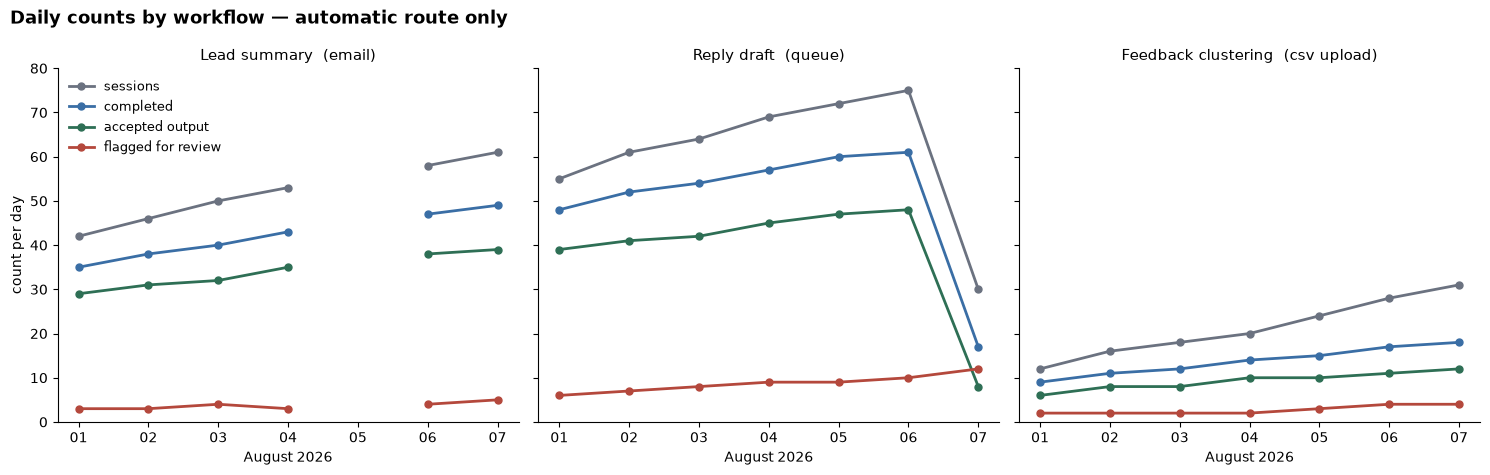

In [32]:
METRICS = ["sessions", "completed", "accepted_output", "flagged_for_review"]
COLOURS = {"sessions": "#6B7280", "completed": "#3A6EA5",
           "accepted_output": "#2E6F55", "flagged_for_review": "#B4483C"}
ORDER = ["Lead summary", "Reply draft", "Feedback clustering"]

# keep the source fixed so a change in the line is a change in the thing
PRIMARY = {"Lead summary": "email", "Reply draft": "queue", "Feedback clustering": "csv upload"}

DATES = sorted(clean_df.date.unique())          # full 7-day spine
LABELS = [d[-2:] for d in DATES]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for a, wf in zip(ax, ORDER):
    sub = (clean_df[(clean_df.workflow == wf) & (clean_df.source == PRIMARY[wf])]
           .set_index("date").reindex(DATES))       # missing day -> NaN -> gap in line
    for m in METRICS:
        a.plot(LABELS, sub[m], "-o", ms=5, lw=2,
               color=COLOURS[m], label=m.replace("_", " "))
    a.set_title(f"{wf}  ({PRIMARY[wf]})", fontsize=11)
    a.set_xlabel("August 2026")
    a.spines[["top", "right"]].set_visible(False)
    a.set_ylim(0, 80)

ax[0].set_ylabel("count per day")
ax[0].legend(fontsize=9, frameon=False, loc="upper left")
fig.suptitle("Daily counts by workflow — automatic route only",
             fontsize=13, fontweight="bold", x=0.01, ha="left")
plt.tight_layout()
plt.show()

Only for feedback clustering there are consistent and increasing sessions

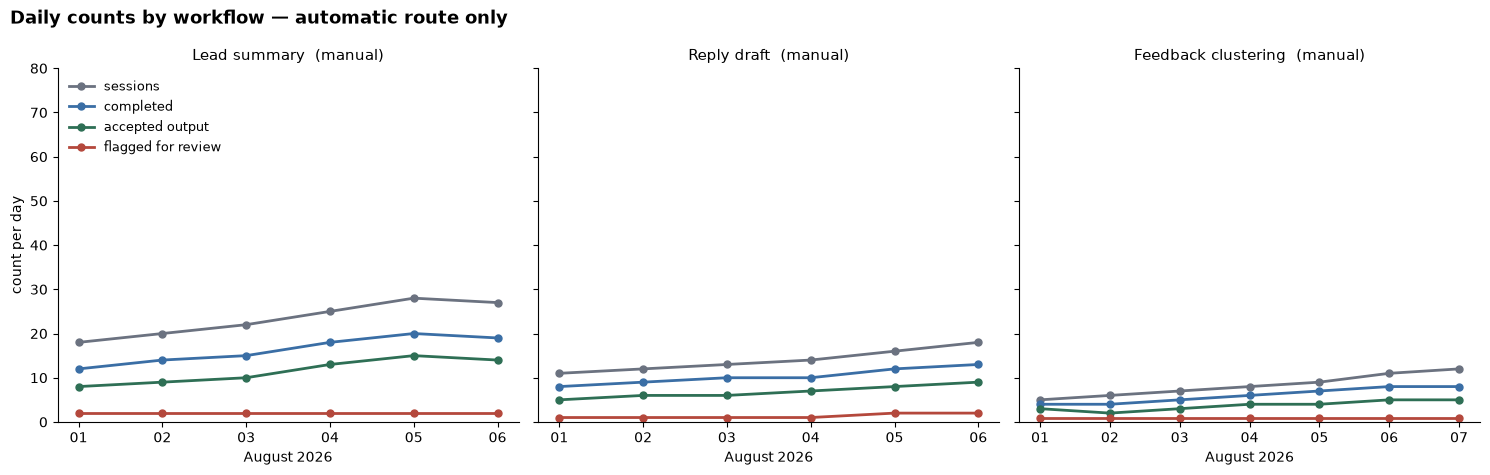

In [33]:
PRIMARY = {"Lead summary": "manual", "Reply draft": "manual", "Feedback clustering": "manual"}

DATES = sorted(clean_df.date.unique())          # full 7-day spine
LABELS = [d[-2:] for d in DATES]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for a, wf in zip(ax, ORDER):
    sub = (clean_df[(clean_df.workflow == wf) & (clean_df.source == PRIMARY[wf])]
           .set_index("date").reindex(DATES))       # missing day -> NaN -> gap in line
    for m in METRICS:
        a.plot(LABELS, sub[m], "-o", ms=5, lw=2,
               color=COLOURS[m], label=m.replace("_", " "))
    a.set_title(f"{wf}  ({PRIMARY[wf]})", fontsize=11)
    a.set_xlabel("August 2026")
    a.spines[["top", "right"]].set_visible(False)
    a.set_ylim(0, 80)

ax[0].set_ylabel("count per day")
ax[0].legend(fontsize=9, frameon=False, loc="upper left")
fig.suptitle("Daily counts by workflow — automatic route only",
             fontsize=13, fontweight="bold", x=0.01, ha="left")
plt.tight_layout()
plt.show()

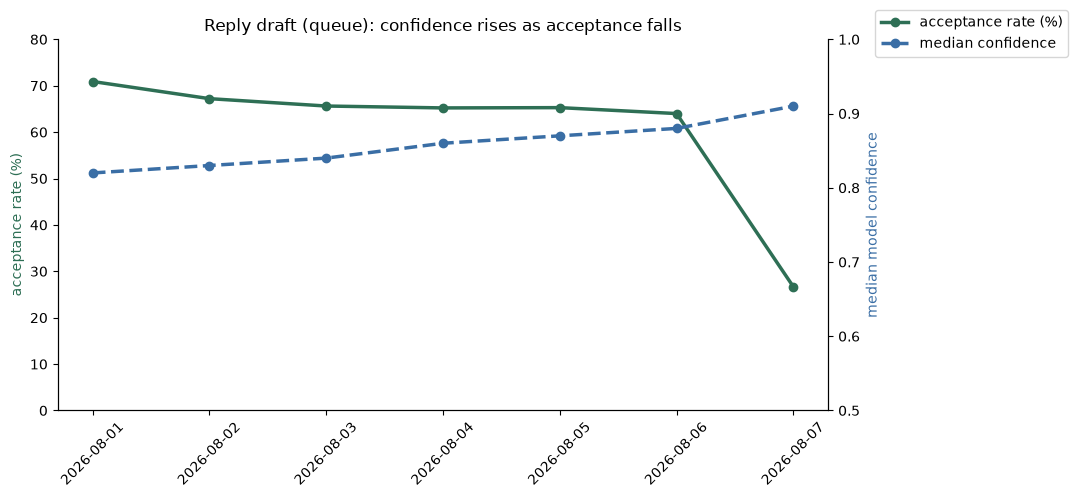

In [34]:
sub = clean_df[(clean_df.workflow == "Reply draft") & (clean_df.source == "queue")].sort_values("date")
sub["accept_rate"] = sub.accepted_output / sub.sessions * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sub.date, sub.accept_rate, "-o", color="#2E6F55", lw=2.5, label="acceptance rate (%)")
ax.set_ylabel("acceptance rate (%)", color="#2E6F55")
ax.set_ylim(0, 80)

ax2 = ax.twinx()
ax2.plot(sub.date, sub.median_confidence, "--o", color="#3A6EA5", lw=2.5,
         label="median confidence")
ax2.set_ylabel("median model confidence", color="#3A6EA5")
ax2.set_ylim(0.5, 1.0)

ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
ax.set_title("Reply draft (queue): confidence rises as acceptance falls")
ax.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)
fig.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

Model confidence increases every day and it is notably the highest on the worst day when the acceptance rate is the lowest. 